# CopulAX Examples
## Elliptical Copula Distributions

This notebook demonstrates the main API for the two core elliptical copulas in CopulAX:

- `gaussian_copula`
- `student_t_copula`

You will see parameter specification, copula-density evaluation, sampling, fitting, JIT compilation, model comparison, and bivariate visualization.

> Note: For Clayton/Frank/Gumbel/Joe/AMH/Independence copulas, see `archimedean_copula_example.ipynb`.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

import jax.numpy as jnp
from jax import jit
from jax.random import split

from copulax import get_random_key
from copulax.copulas import gaussian_copula, student_t_copula

key = get_random_key()


## Parameter Specification

Copula objects use parameter dictionaries with two parts:

- `marginals`: tuple of univariate distributions and their parameters
- `copula`: dependence parameters (for elliptical copulas, this includes a correlation matrix `sigma`)

`example_params(dim=...)` provides a valid template.


In [2]:
dim = 3

# Shared correlation structure for comparisons
sigma = jnp.array([
    [1.00, 0.70, 0.35],
    [0.70, 1.00, 0.30],
    [0.35, 0.30, 1.00],
])

student_params = student_t_copula.example_params(dim=dim)
student_params["copula"]["sigma"] = sigma
student_params["copula"]["nu"] = jnp.asarray(6.0)

gaussian_params = gaussian_copula.example_params(dim=dim)
gaussian_params["copula"]["sigma"] = sigma

models = [
    ("Student-T", student_t_copula, student_params),
    ("Gaussian", gaussian_copula, gaussian_params),
]

print("Student-T params:")
print(student_params)
print("\nGaussian params:")
print(gaussian_params)


Student-T params:
{'marginals': ((Student-T, {'nu': Array(2.5, dtype=float32), 'mu': Array(0., dtype=float32), 'sigma': Array(1., dtype=float32)}), (Student-T, {'nu': Array(2.5, dtype=float32), 'mu': Array(0., dtype=float32), 'sigma': Array(1., dtype=float32)}), (Student-T, {'nu': Array(2.5, dtype=float32), 'mu': Array(0., dtype=float32), 'sigma': Array(1., dtype=float32)})), 'copula': {'nu': Array(6., dtype=float32, weak_type=True), 'mu': Array([[0.],
       [0.],
       [0.]], dtype=float32), 'sigma': Array([[1.  , 0.7 , 0.35],
       [0.7 , 1.  , 0.3 ],
       [0.35, 0.3 , 1.  ]], dtype=float32)}}

Gaussian params:
{'marginals': ((Normal, {'mu': Array(0., dtype=float32), 'sigma': Array(1., dtype=float32)}), (Normal, {'mu': Array(0., dtype=float32), 'sigma': Array(1., dtype=float32)}), (Normal, {'mu': Array(0., dtype=float32), 'sigma': Array(1., dtype=float32)})), 'copula': {'mu': Array([[0.],
       [0.],
       [0.]], dtype=float32), 'sigma': Array([[1.  , 0.7 , 0.35],
       [0.7 

## Copula Density (PDF / Log-PDF)

Copula-level methods operate on uniform marginals `u in [0, 1]^d`:

- `copula_pdf(u, params)`
- `copula_logpdf(u, params)`

This isolates dependence from marginal behavior.


In [3]:
u_points = jnp.array([
    [0.20, 0.30, 0.70],
    [0.50, 0.50, 0.50],
    [0.85, 0.80, 0.15],
])

for name, cop, params in models:
    lp = cop.copula_logpdf(u_points, params)
    p = cop.copula_pdf(u_points, params)
    print(f"{name:10s} logpdf: {lp.flatten()}")
    print(f"{name:10s} pdf:    {p.flatten()}\n")


Student-T  logpdf: [0.3257017  0.64251447 0.13261509]
Student-T  pdf:    [1.3850021 1.9012555 1.1418104]

Gaussian   logpdf: [0.29805112 0.40540266 0.14015007]
Gaussian   pdf:    [1.3472307 1.4999063 1.1504464]



## Generating Copula Samples

Use `copula_rvs(size, params, key)` to sample uniform vectors directly from the copula.

This is useful when you want dependence-only simulation on `[0,1]^d`.


In [4]:
n_u = 1500
for name, cop, params in models:
    key, subkey = split(key)
    u_sample = cop.copula_rvs(size=n_u, params=params, key=subkey)
    emp_corr = jnp.corrcoef(u_sample, rowvar=False)
    print(f"{name:10s} copula sample shape: {u_sample.shape}")
    print(f"{name:10s} first row: {u_sample[0]}")
    print(f"{name:10s} empirical corr:\n{emp_corr}\n")


Student-T  copula sample shape: (1500, 3)
Student-T  first row: [0.20269659 0.04217274 0.06534503]
Student-T  empirical corr:
[[0.99999994 0.6583942  0.29196143]
 [0.6583942  1.         0.27406076]
 [0.29196143 0.27406076 1.        ]]

Gaussian   copula sample shape: (1500, 3)
Gaussian   first row: [0.5339769  0.41028407 0.801188  ]
Gaussian   empirical corr:
[[1.         0.69394183 0.34731603]
 [0.69394183 0.99999994 0.29869807]
 [0.34731603 0.29869807 1.        ]]



## Full Joint Distribution (Sklar's Theorem)

For data on the original scale, use:

- `pdf(x, params)` / `logpdf(x, params)`
- `rvs(size, params, key)`

These combine copula dependence with marginal distributions.


In [5]:
# synthetic training data from a Student-T copula model
n_train = 2000
key, subkey = split(key)
sample = student_t_copula.rvs(size=n_train, params=student_params, key=subkey)
print("Sample shape:", sample.shape)

for name, cop, params in models:
    lp = cop.logpdf(sample[:5], params=params)
    p = cop.pdf(sample[:5], params=params)
    print(f"{name:10s} joint logpdf (first 5): {lp.flatten()}")
    print(f"{name:10s} joint pdf (first 5):    {p.flatten()}\n")


Sample shape: (2000, 3)
Student-T  joint logpdf (first 5): [ -3.2207856  -5.382608  -11.217831   -2.6508577  -6.995935 ]
Student-T  joint pdf (first 5):    [3.9923683e-02 4.5958208e-03 1.3432537e-05 7.0590645e-02 9.1559632e-04]

Gaussian   joint logpdf (first 5): [ -2.8115997  -5.7639427 -29.189558   -2.520986   -8.627716 ]
Gaussian   joint pdf (first 5):    [6.0108759e-02 3.1387121e-03 2.1044375e-13 8.0380306e-02 1.7907316e-04]



## Fitting Copulas to Data

- `fit(x)` fits both marginals and copula parameters on raw data.
- `fit_copula(u)` fits only copula parameters from uniform data.


In [6]:
fitted_student = student_t_copula.fit(sample)
fitted_gaussian = gaussian_copula.fit(sample)

fitted_student_params = fitted_student.params
fitted_gaussian_params = fitted_gaussian.params

print("Fitted Student-T copula params:")
print(fitted_student_params["copula"])
print("\nFitted Gaussian copula params:")
print(fitted_gaussian_params["copula"])

# Copula-only fitting from uniform samples
key, subkey = split(key)
u_train = student_t_copula.copula_rvs(size=n_train, params=student_params, key=subkey)
student_copula_only = student_t_copula.fit_copula(u_train)
gaussian_copula_only = gaussian_copula.fit_copula(u_train)

print("\nTrue Student-T nu:", float(student_params["copula"]["nu"]))
print("Fitted Student-T nu:", float(student_copula_only["copula"]["nu"]))
print("\nTrue sigma:\n", student_params["copula"]["sigma"])
print("Fitted Student-T sigma (copula-only):\n", student_copula_only["copula"]["sigma"])
print("Fitted Gaussian sigma (copula-only):\n", gaussian_copula_only["copula"]["sigma"])


Fitted Student-T copula params:
{'nu': Array(6.498747, dtype=float32), 'mu': Array([[0.],
       [0.],
       [0.]], dtype=float32), 'sigma': Array([[1.0000001 , 0.69758135, 0.36166167],
       [0.6975813 , 1.        , 0.3039967 ],
       [0.3616617 , 0.30399674, 1.        ]], dtype=float32)}

Fitted Gaussian copula params:
{'mu': Array([[0.],
       [0.],
       [0.]], dtype=float32), 'sigma': Array([[1.0000001 , 0.69758135, 0.36166167],
       [0.6975813 , 1.        , 0.3039967 ],
       [0.3616617 , 0.30399674, 1.        ]], dtype=float32)}

True Student-T nu: 6.0
Fitted Student-T nu: 9.304935455322266

True sigma:
 [[1.   0.7  0.35]
 [0.7  1.   0.3 ]
 [0.35 0.3  1.  ]]
Fitted Student-T sigma (copula-only):
 [[1.0000001  0.6901262  0.36720467]
 [0.69012624 1.         0.28985718]
 [0.36720467 0.2898572  1.0000001 ]]
Fitted Gaussian sigma (copula-only):
 [[1.0000001  0.6901262  0.36720467]
 [0.69012624 1.         0.28985718]
 [0.36720467 0.2898572  1.0000001 ]]


## JIT Compilation

Core density and sampling routines are JAX-compatible.


In [7]:
jit_student_copula_logpdf = jit(student_t_copula.copula_logpdf, static_argnames=("brent",))
jit_gaussian_copula_rvs = jit(gaussian_copula.copula_rvs, static_argnums=(0,))

jit_lp = jit_student_copula_logpdf(u_points, student_params)
print("JIT student_t copula_logpdf:", jit_lp.flatten())

key, subkey = split(key)
jit_u = jit_gaussian_copula_rvs(300, gaussian_params, subkey)
print("JIT gaussian copula_rvs shape:", jit_u.shape)


JIT student_t copula_logpdf: [0.32570195 0.6425147  0.13261557]
JIT gaussian copula_rvs shape: (300, 3)


## Model Comparison (AIC / BIC)

AIC/BIC provide quick relative comparison on the same dataset.


In [8]:
scores = []
scores.append((
    "Student-T",
    float(student_t_copula.aic(sample, fitted_student_params)),
    float(student_t_copula.bic(sample, fitted_student_params)),
))
scores.append((
    "Gaussian",
    float(gaussian_copula.aic(sample, fitted_gaussian_params)),
    float(gaussian_copula.bic(sample, fitted_gaussian_params)),
))

print(f"{'Model':12s} {'AIC':>12s} {'BIC':>12s}")
print("-" * 38)
for name, aic, bic in scores:
    print(f"{name:12s} {aic:12.2f} {bic:12.2f}")


Model                 AIC          BIC
--------------------------------------
Student-T        20690.51     20690.51
Gaussian         20905.87     20905.87


## Bivariate Graphs: Uniform Copula Space and Data Space

The top row plots samples in copula space (`u1`, `u2`).
The bottom row plots samples on the original joint data scale (`x1`, `x2`).


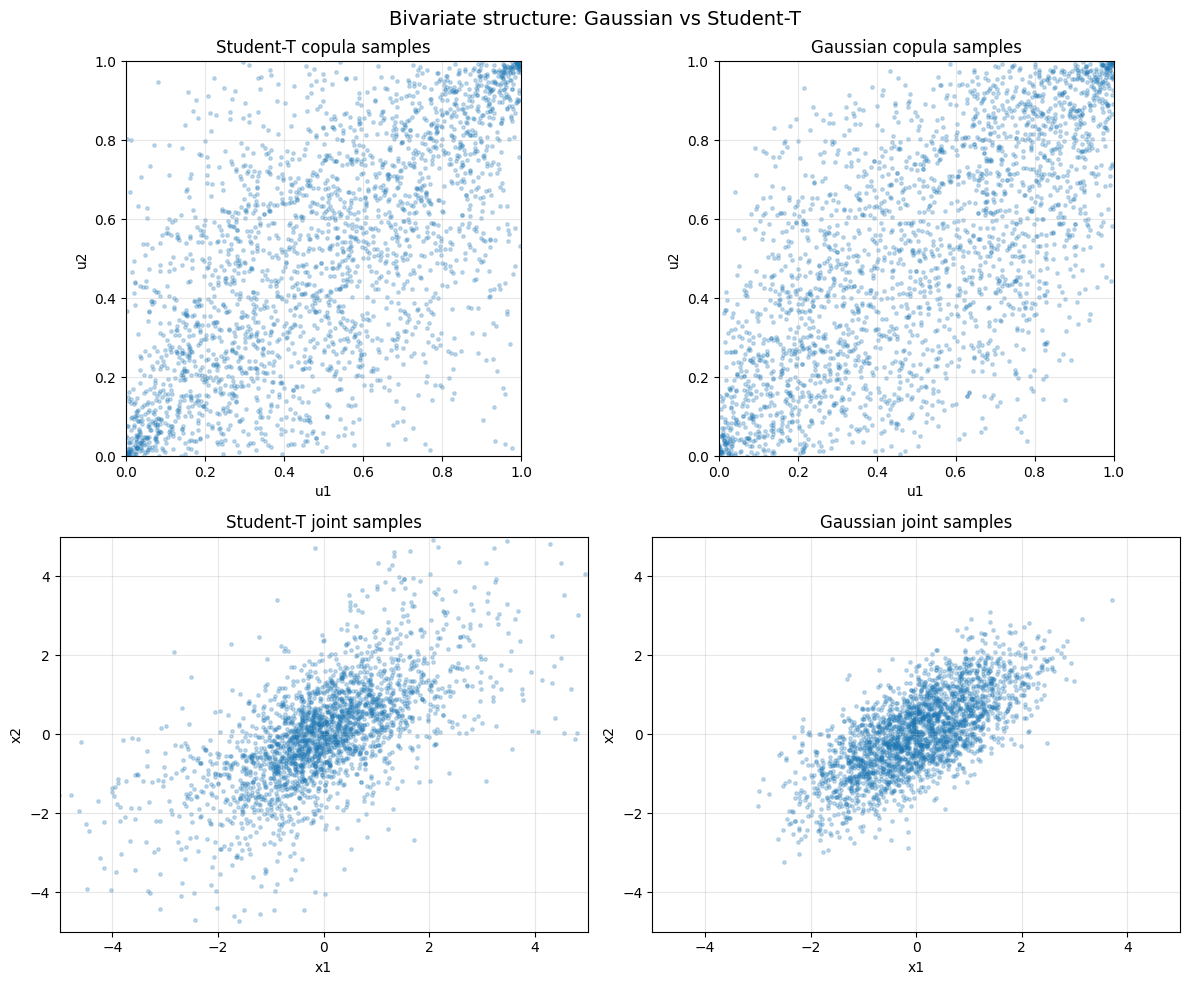

In [9]:
n_plot = 2500

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("Bivariate structure: Gaussian vs Student-T", fontsize=14)

for col, (name, cop, params) in enumerate(models):
    key, subkey = split(key)
    u_draws = np.asarray(cop.copula_rvs(size=n_plot, params=params, key=subkey))

    key, subkey = split(key)
    x_draws = np.asarray(cop.rvs(size=n_plot, params=params, key=subkey))

    ax_u = axes[0, col]
    ax_u.scatter(u_draws[:, 0], u_draws[:, 1], alpha=0.25, s=6)
    ax_u.set_title(f"{name} copula samples")
    ax_u.set_xlabel("u1")
    ax_u.set_ylabel("u2")
    ax_u.set_xlim(0, 1)
    ax_u.set_ylim(0, 1)
    ax_u.set_aspect("equal")
    ax_u.grid(alpha=0.3)

    ax_x = axes[1, col]
    ax_x.scatter(x_draws[:, 0], x_draws[:, 1], alpha=0.25, s=6)
    ax_x.set_title(f"{name} joint samples")
    ax_x.set_xlabel("x1")
    ax_x.set_ylabel("x2")
    ax_x.set_xlim(-5, 5)
    ax_x.set_ylim(-5, 5)
    ax_x.grid(alpha=0.3)

plt.tight_layout()
plt.show()


## Bivariate Graphs: Density Heatmaps

Heatmaps make local concentration and tail regions easier to compare.


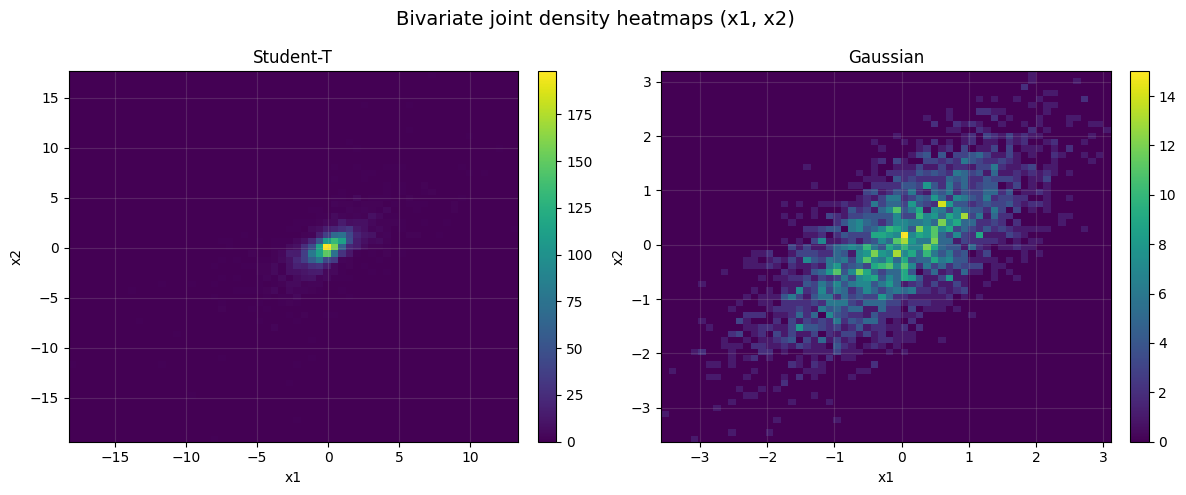

In [10]:
n_heat = 3000
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Bivariate joint density heatmaps (x1, x2)", fontsize=14)

for ax, (name, cop, params) in zip(axes, models):
    key, subkey = split(key)
    x_draws = np.asarray(cop.rvs(size=n_heat, params=params, key=subkey))
    h = ax.hist2d(x_draws[:, 0], x_draws[:, 1], bins=60, cmap="viridis")
    ax.set_title(name)
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.grid(alpha=0.2)
    fig.colorbar(h[3], ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


## Saving and Loading Fitted Copulas

Fitted copulas (including their marginal distributions) can be saved to disk and loaded back in a later session. Files use the `.cpx` format and are cross-platform.

In [11]:
import copulax

# save the fitted copula (marginals + dependence structure)
fitted_student.save("fitted_student_t_copula.cpx")

# load it back
loaded_cop = copulax.load("fitted_student_t_copula.cpx")
print("loaded copula params:", loaded_cop.params["copula"])

# verify identical output
original_lp = fitted_student.logpdf(sample[:5])
loaded_lp = loaded_cop.logpdf(sample[:5])
print("logpdf matches:", jnp.allclose(original_lp, loaded_lp))

# clean up
import os
os.remove("fitted_student_t_copula.cpx")

loaded copula params: {'nu': Array(6.498747, dtype=float32), 'mu': Array([[0.],
       [0.],
       [0.]], dtype=float32), 'sigma': Array([[1.0000001 , 0.69758135, 0.36166167],
       [0.6975813 , 1.        , 0.3039967 ],
       [0.3616617 , 0.30399674, 1.        ]], dtype=float32)}
logpdf matches: True


## Summary

This notebook covered the full workflow for CopulAX elliptical copulas:

| Feature | API |
|---|---|
| Example parameters | `example_params(dim)` |
| Copula density | `copula_pdf(u, params)` / `copula_logpdf(u, params)` |
| Copula sampling | `copula_rvs(size, params, key)` |
| Joint density/sampling | `pdf(x, params)` / `logpdf(x, params)` / `rvs(size, params, key)` |
| Fitting | `fit(x)` / `fit_copula(u)` |
| Model selection | `aic(x, params)` / `bic(x, params)` |
| Save/load | `save(path)` / `copulax.load(path)` |
| Performance | JAX `jit` compatibility |